In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from src.processing import WESADDataset
from src.features import process_subject_data

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [4]:
# Reload data
loader = WESADDataset('../data/WESAD')
df_raw = loader.load_subject('S2')
df     = loader.filter_target_states(df_raw)

feature_df   = process_subject_data(df)
X            = feature_df.drop('Label', axis=1).values
y            = feature_df['Label'].values
feature_names = feature_df.drop('Label', axis=1).columns.tolist()

# Load saved model and scaler
rf      = joblib.load('../models/random_forest.pkl')
scaler  = joblib.load('../models/scaler.pkl')
X_scaled = scaler.transform(X)

print(f"Data loaded: {X_scaled.shape}")
print(f"Features: {feature_names}")

Loading S2 data... This might take a moment.
Extracting features using 60-second windows...
Data loaded: (29, 7)
Features: ['HRV_RMSSD', 'HRV_MeanNN', 'Mean_HR', 'EDA_Tonic_Mean', 'EDA_Phasic_Mean', 'Temp_Mean', 'Resp_Std']


In [ ]:
## What is SHAP?

SHAP (SHapley Additive exPlanations) answers the question:
*"For this specific prediction, how much did each feature contribute?"*

for example each feature is a player in a game,
and the prediction is the prize. SHAP fairly distributes the prize among
players based on their contribution.

- **Positive SHAP value** → pushed prediction toward Stress (1)
- **Negative SHAP value** → pushed prediction toward Baseline (0)
- **SHAP = 0** → that feature had no influence on this prediction

This tells not just WHAT the model predicts, but WHY.

In [6]:
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_scaled)

# Newer SHAP versions return shap_values as a 3D array (n_samples, n_features, n_classes)
# Older versions return a list of arrays, one per class
# This handles both cases:
if isinstance(shap_values, list):
    # Old format: list[class_index] → (n_samples, n_features)
    shap_stress = shap_values[1]
else:
    # New format: 3D array → slice class 1
    shap_stress = shap_values[:, :, 1]

print(f"SHAP values shape (stress class): {shap_stress.shape}")
print(f"Expected: ({X_scaled.shape[0]} windows, {len(feature_names)} features)")
print(f"\nMean |SHAP| per feature (global importance):")

mean_shap  = np.abs(shap_stress).mean(axis=0)
importance = pd.Series(mean_shap, index=feature_names).sort_values(ascending=False)
print(importance.round(4))

SHAP values shape (stress class): (29, 7)
Expected: (29 windows, 7 features)

Mean |SHAP| per feature (global importance):
Temp_Mean          0.1186
Resp_Std           0.0917
HRV_RMSSD          0.0837
Mean_HR            0.0555
HRV_MeanNN         0.0470
EDA_Tonic_Mean     0.0231
EDA_Phasic_Mean    0.0174
dtype: float64


In [ ]:
## SHAP Findings — Subject S2

### Global Feature Importance (Mean |SHAP|)
1. Temp_Mean (0.119) — strongest discriminator
2. Resp_Std (0.092) — breathing irregularity under stress
3. HRV_RMSSD (0.084) — reduced heart rate variability under stress

### Notable Observation
EDA_Tonic_Mean ranks 6th despite showing clear visual separation in
notebook 03. This may reflect: (a) small sample size allowing the model
to rely on simpler features, and (b) temporal alignment artifacts in the
EDA signal discussed in notebook 02. Multi-subject validation would
clarify whether EDA's contribution increases with more data.

### Consistency with Visual Analysis
Top 3 features align with observations from notebooks 02 and 03:
- Temperature showed near-perfect distributional separation
- Respiration showed visibly irregular patterns during stress
- HRV_RMSSD showed expected reduction under sympathetic activation

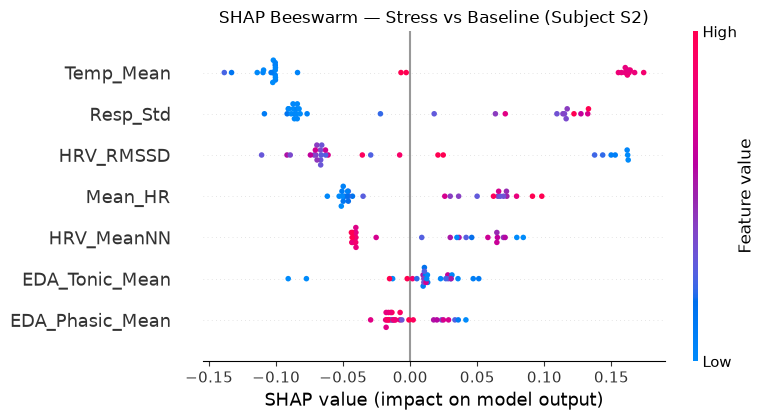

In [7]:
# Beeswarm shows both importance AND direction
# Each dot = one window
# Color = feature value (red = high, blue = low)
# X position = SHAP value (right = pushed toward stress)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_stress, X_scaled,
    feature_names=feature_names,
    show=False,
    plot_type='dot'
)
plt.title('SHAP Beeswarm — Stress vs Baseline (Subject S2)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

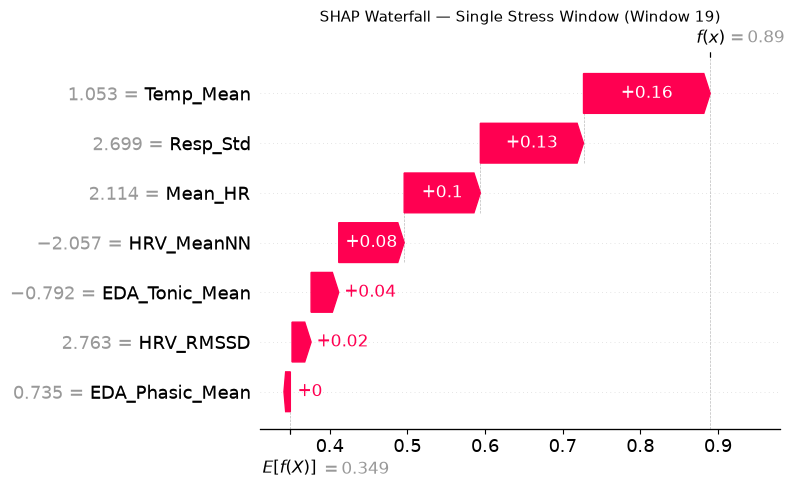

In [8]:
# Pick one stress window to explain individually
stress_indices = np.where(y == 1)[0]
sample_idx = stress_indices[0]

# Create SHAP Explanation object
explanation = shap.Explanation(
    values     = shap_stress[sample_idx],
    base_values = explainer.expected_value[1],
    data       = X_scaled[sample_idx],
    feature_names = feature_names
)

plt.figure(figsize=(10, 5))
shap.plots.waterfall(explanation, show=False)
plt.title(f'SHAP Waterfall — Single Stress Window (Window {sample_idx})', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()